# Analysis of the PBG from stats

Cavity-like structures: $\chi=0.37$ is fixed and $\epsilon$ is swept (43, 45, 47).

`all_bands` has shape (Nbands, Nk, Nsamples); the k-path is $\Gamma$-X-M-$\Gamma$ with the
closing $\Gamma$ dropped, and `G_index`/`X_index`/`M_index` are **1-based**.

In [1]:
%matplotlib widget
import IO_h5py as IO
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


**lists to create names of files with all data**

file_name = rf"../Luis Data/Cavity_Like_Structures_h5/eps_{eps}_bands/chi_0.{chi}_band_sampling.h5"

In [2]:
chi='37'
eps_names=['43','45','47','50']
eps_values=np.array([float(e) for e in eps_names])

**Testing for $\epsilon=43$**

In [3]:
eps_n=0
eps=eps_names[eps_n]
file_name = rf"../Luis Data/Cavity_Like_Structures_h5/eps_{eps}_bands/chi_0.{chi}_band_sampling.h5"
band_sampling=IO.read_dict_hdf5(file_name)
print('X_index=',band_sampling['X_index'],'(1-based)')

#writing first sample results to a file. Only Gamma and X points to compare with other MPB
X=band_sampling['X_index']-1   #0-based column of the X point
salida=np.vstack([band_sampling['all_bands'][:300,0,0],band_sampling['all_bands'][:300,X,0]])
np.savetxt(f'fortran_code_1_sample_chi_0.{chi}_eps_{eps}.csv', salida, delimiter=',')

X_index= 11 (1-based)


G_index
Gamma
M
M_index
Nbands
Nk
Npartic
Nsamples
X
X_index
all_bands
all_posics
chi
eps
interpolate
k_array
k_path_length
kmag_over_2pi
lattice_size
polarization
radius
resolution
sample_ids
chi= 0.37 eps= 50.0
(800, 30, 8)


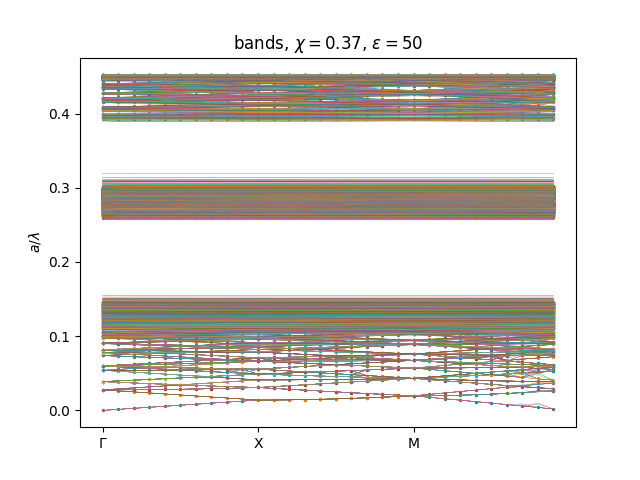

In [17]:
eps=eps_names[-1]
file_name = rf"../Luis Data/Cavity_Like_Structures_h5/eps_{eps}_bands/chi_0.{chi}_band_sampling.h5"
band_sampling=IO.read_dict_hdf5(file_name)
for k in band_sampling.keys():
    print(k)
print('chi=',band_sampling['chi'],'eps=',band_sampling['eps'])
print(band_sampling['all_bands'].shape) #(Nbands, Nk, Nsamples)

n_plot=800   #bands to draw
ind=np.arange(band_sampling['Nk'])

fig,ax = plt.subplots()
for i in range(n_plot):
    for j in range(1,band_sampling['Nsamples']):
        ax.plot(ind,band_sampling['all_bands'][i,:,j],lw=0.3)

for i in range(n_plot):
    ax.scatter(ind,band_sampling['all_bands'][i,:,0],s=2)

#high symmetry points along the stored path (indices are 1-based in the file)
ax.set_xticks([band_sampling['G_index']-1,band_sampling['X_index']-1,band_sampling['M_index']-1])
ax.set_xticklabels([r'$\Gamma$','X','M'])
ax.set_ylabel(r'$a/\lambda$')
ax.set_title(rf'bands, $\chi=0.{chi}$, $\epsilon={eps}$')
plt.show()

**Frequency histograms over the whole k-path, one per $\epsilon$**

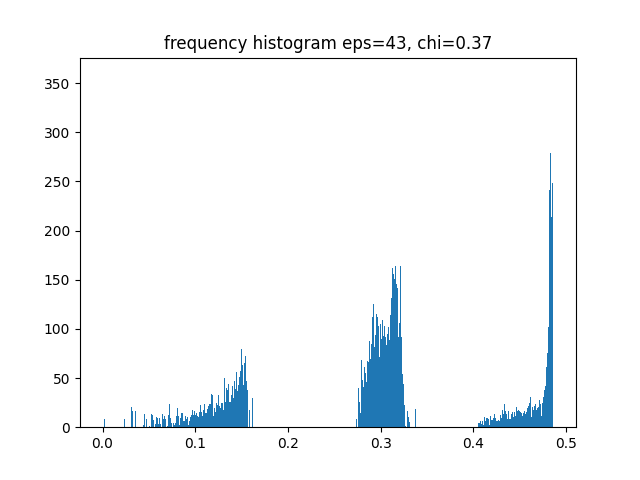

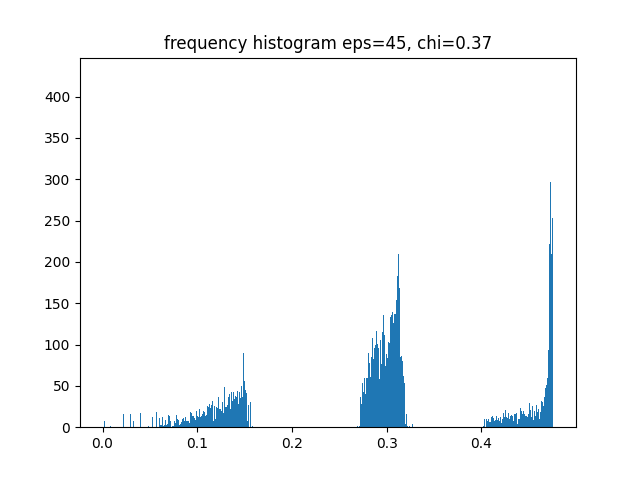

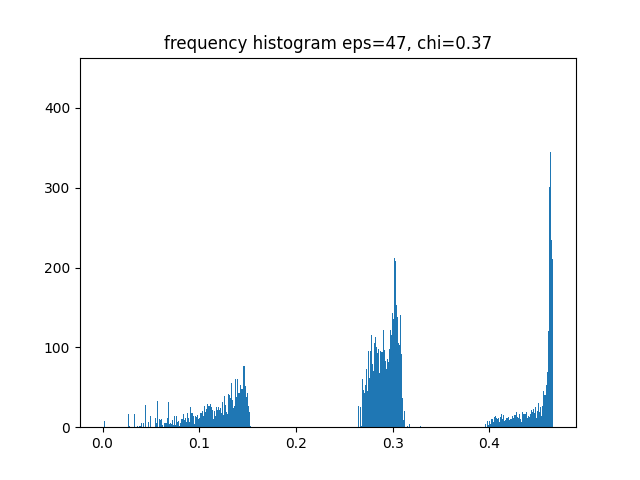

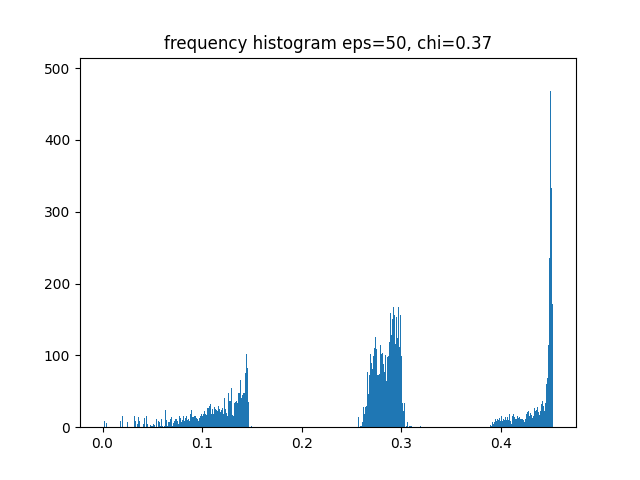

In [5]:
for eps in eps_names:
    file_name = rf"../Luis Data/Cavity_Like_Structures_h5/eps_{eps}_bands/chi_0.{chi}_band_sampling.h5"
    band_sampling=IO.read_dict_hdf5(file_name)

    fig,ax = plt.subplots()
    n_bins=10000
    ax.hist(band_sampling['all_bands'].flatten(), bins=n_bins)
    ax.set_title(f'frequency histogram eps={eps}, chi=0.{chi}')
    plt.show()

**Automatic gap edges**: largest empty interval of the pooled spectrum above `nu_min`.
Use it as a starting point for the by-hand values in the next cell.

In [6]:
nu_min=0.2   #ignore the low frequency region, the spectrum is dense there

auto_gaps={}
for eps in eps_names:
    file_name = rf"../Luis Data/Cavity_Like_Structures_h5/eps_{eps}_bands/chi_0.{chi}_band_sampling.h5"
    band_sampling=IO.read_dict_hdf5(file_name)
    freqs=np.sort(band_sampling['all_bands'].flatten())
    freqs=freqs[freqs>nu_min]
    i=np.argmax(np.diff(freqs))
    lower,upper=freqs[i],freqs[i+1]
    auto_gaps[eps]=[lower,upper]
    print(f'eps={eps}: gap=[{lower:.4f},{upper:.4f}]  '
          f'vc={(upper+lower)/2:.4f}  relative width={200*(upper-lower)/(upper+lower):.2f} %  '
          f'(Nsamples={band_sampling["Nsamples"]})')

eps=43: gap=[0.3433,0.4051]  vc=0.3742  relative width=16.51 %  (Nsamples=8)
eps=45: gap=[0.3359,0.4005]  vc=0.3682  relative width=17.53 %  (Nsamples=8)
eps=47: gap=[0.3290,0.3960]  vc=0.3625  relative width=18.48 %  (Nsamples=8)
eps=50: gap=[0.3193,0.3894]  vc=0.3544  relative width=19.77 %  (Nsamples=8)


**To be more precise, we go by hand with the histograms to calculate the PBG margins**

In [7]:
#values from the automatic search above, refine by eye on the histograms if needed
v=[0.3433,0.4051] #eps=43
v=[0.3359,0.4005] #eps=45
v=[0.3290,0.3960] #eps=47
v=[0.3193,0.3894] #eps=50

D=v[1]-v[0]
vc=(v[1]+v[0])/2.
rel=D/vc
print('vc=',vc) 
print('relative width=',rel*100,'%')

vc= 0.35435
relative width= 19.782700719627503 %


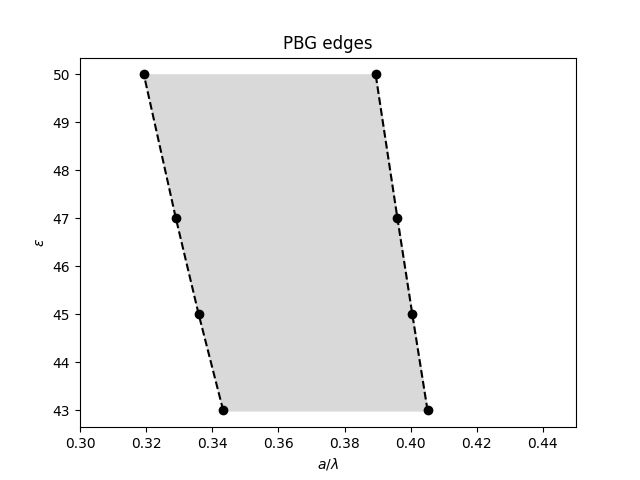

In [12]:
#[[lower edges],[upper edges],[eps]]
PBG_boundaries=[[0.3433,0.3359,0.3290,0.3193],
                [0.4051,0.4005,0.3960,0.3894],
                [43.   ,45.   ,47.  ,50. ]]

lower,upper,eps_axis=[np.array(row) for row in PBG_boundaries]

fig,ax = plt.subplots()
ax.plot(lower,eps_axis,'ko--')
ax.plot(upper,eps_axis,'ko--')
ax.fill_betweenx(eps_axis,lower,upper,color='0.85')
ax.set_title('PBG edges')
ax.set_xlabel(r'$a/ \lambda$')
ax.set_ylabel(r'$\epsilon$')
ax.set_xlim(0.3,0.45)
plt.show()

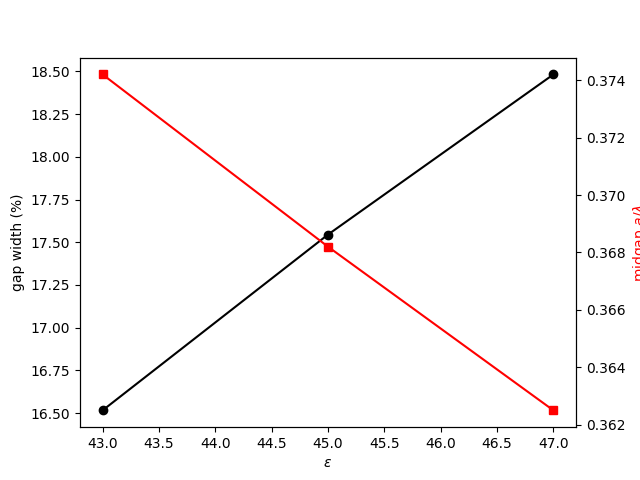

eps=43: [0.3433,0.4051]  width=16.52 %
eps=45: [0.3359,0.4005]  width=17.54 %
eps=47: [0.3290,0.3960]  width=18.48 %


In [9]:
#gap width and midgap against eps
width=200*(upper-lower)/(upper+lower)
midgap=(upper+lower)/2.

fig,ax = plt.subplots()
ax.plot(eps_axis,width,'ko-')
ax.set_xlabel(r'$\epsilon$')
ax.set_ylabel(r'gap width (%)')
ax2=ax.twinx()
ax2.plot(eps_axis,midgap,'rs-')
ax2.set_ylabel(r'midgap $a/\lambda$',color='r')
plt.show()

for e,l,u,w in zip(eps_axis,lower,upper,width):
    print(f'eps={e:.0f}: [{l:.4f},{u:.4f}]  width={w:.2f} %')

In [10]:
print(band_sampling['all_bands'].shape)

print(band_sampling['X_index'])

(800, 30, 8)
11


**Same histograms, restricted to the $\Gamma$ point**

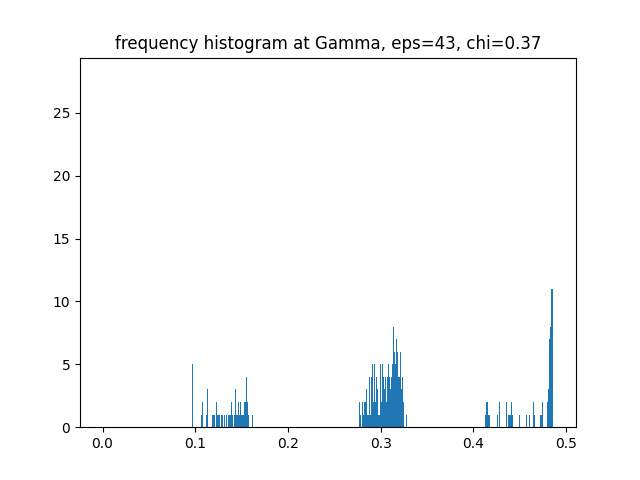

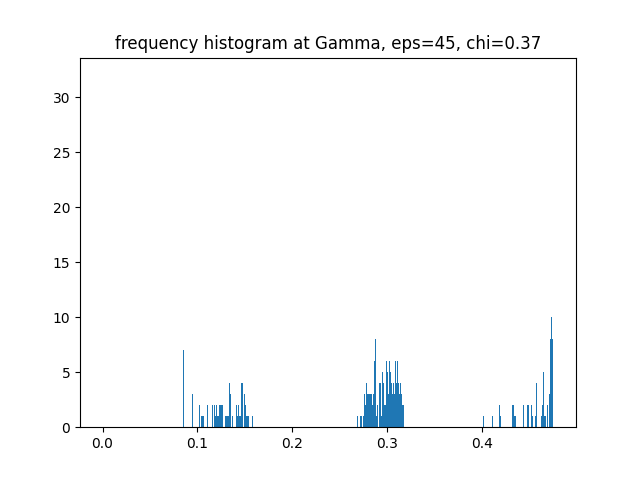

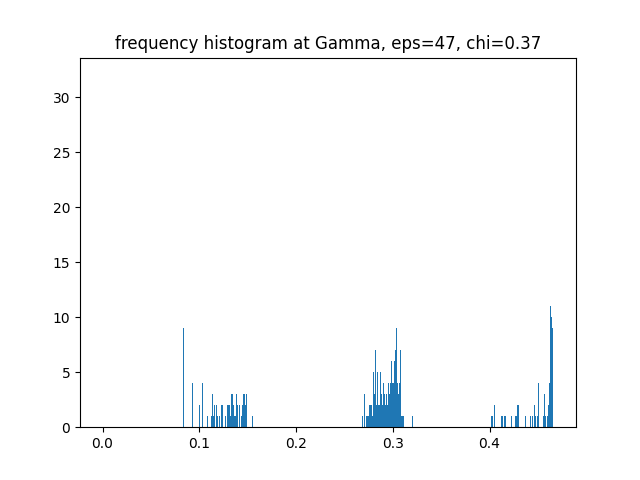

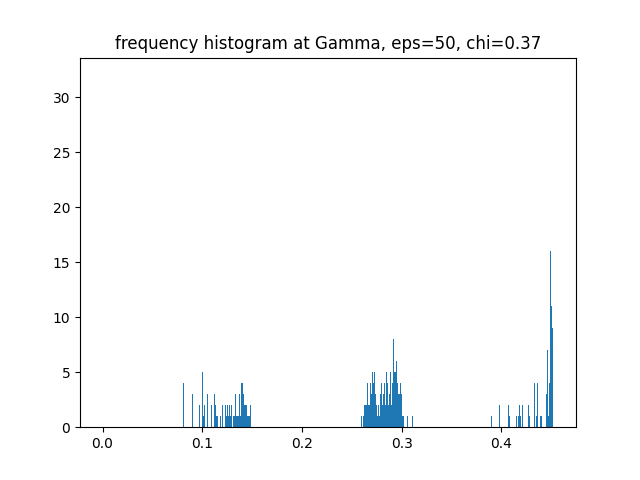

In [11]:
for eps in eps_names:
    file_name = rf"../Luis Data/Cavity_Like_Structures_h5/eps_{eps}_bands/chi_0.{chi}_band_sampling.h5"
    band_sampling=IO.read_dict_hdf5(file_name)

    fig,ax = plt.subplots()
    n_bins=10000
    ax.hist(band_sampling['all_bands'][:,band_sampling['G_index']-1,:].flatten(), bins=n_bins)
    ax.set_title(f'frequency histogram at Gamma, eps={eps}, chi=0.{chi}')
    plt.show()